In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from scripts.data_loader import DataLoader
from scripts.analyzer import FinancialAnalyzer

# 1. Load News Data (Task 1 & 2)
loader = DataLoader('../data/raw_analyst_ratings.csv')
news_df = loader.load_data()
news_df = loader.clean_data()
news_df['sentiment_score'] = news_df['headline'].apply(FinancialAnalyzer.get_sentiment)

# 2. Load Stock Data (Task 3)
stock_df = pd.read_csv('../data/AAPL.csv')
stock_df = FinancialAnalyzer.calculate_technical_indicators(stock_df)

# 3. Task 4: Run Correlation
corr_val, merged_data = FinancialAnalyzer.run_correlation(news_df, stock_df)

print(f"✅ Task 4 Complete!")
print(f"📊 The Pearson Correlation Coefficient is: {corr_val:.4f}")

✅ Loaded 1407328 rows.
✅ Data cleaning complete.
✅ Task 4 Complete!
📊 The Pearson Correlation Coefficient is: -0.0028


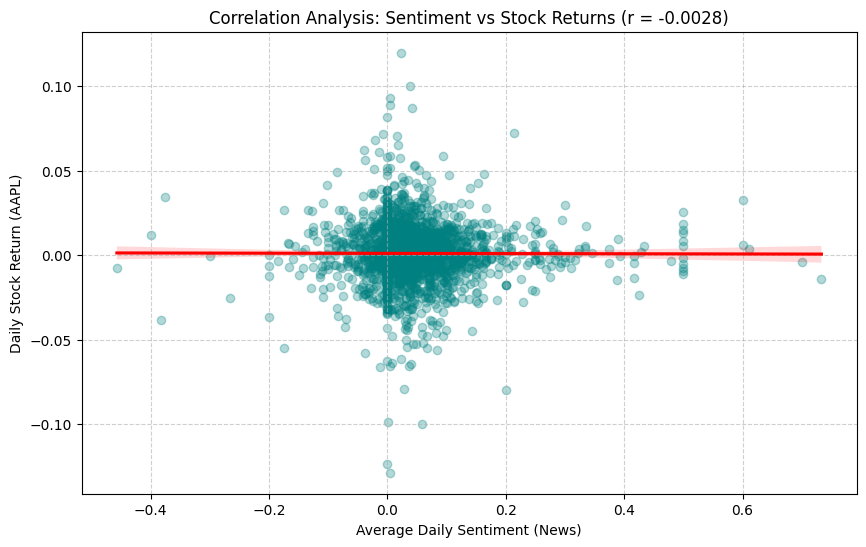

In [2]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Avg_Sentiment', y='Daily_Return', data=merged_data, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})
plt.title(f"Correlation Analysis: Sentiment vs Stock Returns (r = {corr_val:.4f})")
plt.xlabel("Average Daily Sentiment (News)")
plt.ylabel("Daily Stock Return (AAPL)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()